# Project 2 Part II (Core)

*Project 2: Initial Analysis and Problem Selection*

## Objective

Perform data preprocessing and machine learning model optimization for the selected dataset. The goal is to choose the most suitable machine learning technique and optimize its hyperparameters in order to achieve the best possible performance.

# Part II: Preprocessing and Optimization

# Problem Statement

Develop a predictive model to estimate individual calorie needs and identify nutritional risk patterns to support preventive healthcare and personalized dietary recommendations.

# Dataset Description

This dataset contains demographic, biometric, lifestyle, and dietary information, including age, gender, height, weight, physical activity, dietary habits, and calorie intake.

## Dataset Source

This project uses the Healthy Diet and Calorie Intake dataset from Kaggle. The dataset contains records for 6,000 individuals and includes 15 features related to demographics, lifestyle, diet, and health. Variables include age, gender, height, weight, BMI, activity level, diet type, protein, carbohydrate and fat intake, water consumption, daily calorie needs and intake, and health status.

The dataset is available at: [https://www.kaggle.com/datasets/aliyasaly1231/healthy-diet-and-calorie-intake](https://www.kaggle.com/datasets/aliyasaly1231/healthy-diet-and-calorie-intake).

## Dataset Information

- Number of observations: **6000**
- Number of features: **15**
- Target variable: `Health_Status`

## Data Dictionary

| Column Name                   | Data Type                | Description                                                                                                                                          | Example     |
| ----------------------------- | ------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------- | ----------- |
| **Person_ID**                 | String                   | Unique identifier for each individual.                                                                              | P0001       |
| **Age**                       | Integer                  | Age of the individual in years.                                                                                                                      | 50          |
| **Gender**                    | String                   | Gender of the individual. Possible values: Male, Female, Other.                                                                                      | Male        |
| **Height_cm**                 | Float                    | Height measured in centimeters. Used in BMI calculation.                                                                                             | 176.4       |
| **Weight_kg**                 | Float                    | Body weight measured in kilograms.                                                                                                                   | 74.8        |
| **BMI**                       | Float                    | Body Mass Index calculated as weight (kg) / height (m)². Used to assess weight status.                                                               | 24.0        |
| **Activity_Level**            | String                   | Physical activity category. Values include Sedentary, Lightly Active, Moderately Active, Very Active, and Athlete.                                   | Very Active |
| **Daily_Calorie_Requirement** | Integer                  | Estimated daily calorie requirement based on age, gender, height, weight, and activity level (TDEE).                                                 | 2852        |
| **Daily_Calorie_Consumed**    | Integer                  | Actual number of calories consumed per day.                                                                                                          | 2625        |
| **Protein_Intake_g**          | Float                    | Daily protein intake measured in grams.                                                                                                              | 183.0       |
| **Carbohydrate_Intake_g**     | Float                    | Daily carbohydrate intake measured in grams.                                                                                                         | 16.9        |
| **Fat_Intake_g**              | Float                    | Daily fat intake measured in grams.                                                                                                                  | 202.8       |
| **Water_Intake_Liters**       | Float                    | Daily water consumption measured in liters.                                                                                                          | 3.3         |
| **Diet_Type**                 | String                   | Dietary pattern followed by the individual. Values include Keto, Vegan, Balanced, Mediterranean, High Protein, and Vegetarian.                       | Keto        |
| **Health_Status**             | String (Target Variable) | Health classification of the individual. Categories: Healthy, Overweight, Obese, Underweight.  | Healthy     |

**Note**

**TDEE** is **Total Daily Energy Expenditure**.

It is the estimated number of calories a person burns in a day, including:

- **Basal Metabolic Rate (BMR):** Calories needed for basic body functions (breathing, circulation, etc.).
- **Physical Activity:** Calories burned through exercise and daily movement.
- **Thermic Effect of Food (TEF):** Calories used to digest and process food.

In this dataset, **Daily_Calorie_Requirement** represents the individual's TDEE, which is calculated based on factors such as age, gender, height, weight, and activity level.

Example:

- TDEE = 2,500 calories/day
- Calories consumed = 2,200 calories/day
- Result = **300-calorie deficit** (may lead to weight loss if sustained)

Or:

- TDEE = 2,500 calories/day
- Calories consumed = 2,800 calories/day
- Result = **300-calorie surplus** (may lead to weight gain if sustained)

---

# Data Loading and Inspection

## Import Libraries

In [ ]:
# Standard library imports
import math
from pathlib import Path
import time

# Third-party imports
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    FunctionTransformer
)
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Bagging
from sklearn.ensemble import BaggingClassifier
# Logistic Regression
from sklearn.linear_model import LogisticRegression
# Random Forest
from sklearn.ensemble import RandomForestClassifier
# XGBoost
from xgboost import XGBClassifier

from lazypredict.Supervised import LazyClassifier

import optuna

import joblib

### Dataset Availability and Path Setup

In [41]:
data_dir = Path("")

# List available files (for verification)
available_files = list(data_dir.iterdir())
print("Available files:", available_files)
file_name = "3_healthy_diet.csv"
dataset_path = data_dir / file_name

Available files: [WindowsPath('3_EDA_healthy_diet.ipynb'), WindowsPath('3_healthy_diet.csv'), WindowsPath('core_8_project_2_part_2.ipynb')]


In [42]:
# Validate dataset existence
if not dataset_path.exists():
    raise FileNotFoundError(f"{file_name} not found in {data_dir}")

print("Dataset found at:", dataset_path)

Dataset found at: 3_healthy_diet.csv


## Load Dataset

In [43]:
df = pd.read_csv(dataset_path)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  6000 non-null   str    
 1   Age                        6000 non-null   int64  
 2   Gender                     6000 non-null   str    
 3   Height_cm                  6000 non-null   float64
 4   Weight_kg                  6000 non-null   float64
 5   BMI                        6000 non-null   float64
 6   Activity_Level             6000 non-null   str    
 7   Daily_Calorie_Requirement  6000 non-null   int64  
 8   Daily_Calorie_Consumed     6000 non-null   int64  
 9   Protein_Intake_g           6000 non-null   float64
 10  Carbohydrate_Intake_g      6000 non-null   float64
 11  Fat_Intake_g               6000 non-null   float64
 12  Water_Intake_Liters        6000 non-null   float64
 13  Diet_Type                  6000 non-null   str    
 14  Hea

---

# Planned Feature Preprocessing
| Column                      | Variable Type                 | Planned Treatment                      | Encoding / Scaling Strategy       | Reason                                                               |
| --------------------------- | ----------------------------- | -------------------------------------- | --------------------------------- | -------------------------------------------------------------------- |
| `Person_ID`                 | Identifier                    | Remove before modeling                 | None                              | Unique identifier with no predictive value                           |
| `Age`                       | Numerical (Discrete)          | Scale                                  | `MinMaxScaler`                    | No significant outliers detected; bounded age range                  |
| `Gender`                    | Nominal Categorical           | Encode categorical values              | One-Hot Encoding (`drop='first'`) | No inherent ordering among categories                                |
| `Height_cm`                 | Continuous Numerical          | Preserve outliers + scale              | `StandardScaler`                  | Approximately normal distribution; outliers retained                 |
| `Weight_kg`                 | Continuous Numerical          | Preserve outliers + scale              | `StandardScaler`                  | Bell-shaped distribution with some extreme values                    |
| `BMI`                       | Continuous Numerical          | Preserve outliers + scale              | `StandardScaler`                  | Approximately normal distribution and clinically meaningful outliers |
| `Activity_Level`            | Ordinal Categorical           | Encode preserving order                | Ordinal Encoding                  | Categories represent increasing activity intensity                   |
| `Daily_Calorie_Requirement` | Continuous Numerical          | Preserve outliers + scale              | `StandardScaler`                  | Approximately bell-shaped distribution                               |
| `Daily_Calorie_Consumed`    | Continuous Numerical          | Preserve outliers + scale              | `StandardScaler`                  | Approximately bell-shaped distribution                               |
| `Protein_Intake_g`          | Continuous Numerical          | Investigate log transformation + scale | `log1p()` + `RobustScaler`        | Positively skewed with high-end outliers                             |
| `Carbohydrate_Intake_g`     | Continuous Numerical          | Remove invalid values, then scale      | `StandardScaler` (after cleaning) | Mostly bell-shaped with slight asymmetry                             |
| `Fat_Intake_g`              | Continuous Numerical          | Investigate log transformation + scale | `log1p()` + `RobustScaler`        | Positively skewed with long right tail                               |
| `Water_Intake_Liters`       | Continuous Numerical          | Preserve outliers + scale              | `StandardScaler`                  | Near-normal distribution with mild skew                              |
| `Diet_Type`                 | Nominal Categorical           | Encode categorical values              | One-Hot Encoding (`drop='first'`) | Categories have no natural ordering                                  |
| `Health_Status`             | Categorical (Target Variable) | Keep as target variable                | Label Encoding                    | Multi-class classification target                                    |

**Additional Notes**

- **Ordinal Encoding Order for `Activity_Level`:**

  - Sedentary = 0
  - Lightly Active = 1
  - Moderately Active = 2
  - Very Active = 3
  - Athlete = 4

- **Label Encoding for `Health_Status`:**

  - Underweight = 0
  - Healthy = 1
  - Overweight = 2
  - Obese = 3

- Since **BMI is derived from Height and Weight**, check for multicollinearity during EDA. For linear models, consider removing either BMI or the raw height/weight variables if variance inflation is high.

- If tree-based models (Random Forest, XGBoost, LightGBM) are used, scaling may not be necessary, but keeping a consistent preprocessing pipeline is often beneficial for model comparison.

## Data Cleaning Actions

| Issue Identified                           | Planned Action          | Reason                                                                                  |
| ------------------------------------------ | ----------------------- | --------------------------------------------------------------------------------------- |
| Negative values in `Carbohydrate_Intake_g` | Remove affected records | Negative carbohydrate intake is physically impossible and indicates data quality issues |
| Outliers in all features except `Age`      | Preserve initially      | Outliers may represent valid physiological variation rather than errors                 |
| Class imbalance in `Health_Status`         | Address during modeling | Overweight class dominates dataset and may bias predictions                             |

## Feature Relationship Analysis

| Analysis                                   | Planned Action                                              | Reason                                                                    |
| ------------------------------------------ | ----------------------------------------------------------- | ------------------------------------------------------------------------- |
| `Height_cm`, `Weight_kg`, and `BMI`        | Evaluate multicollinearity using correlation matrix and VIF | BMI is derived from height and weight, potentially introducing redundancy |
| Nutritional intake features                | Examine correlations                                        | Protein, carbohydrate, and fat intake may be strongly related             |
| Calorie requirement vs calorie consumption | Assess feature dependence                                   | Potentially high correlation that may affect some models                  |

## Class Imbalance Strategy

| Observation                                                                               | Planned Action                                                  |
| ----------------------------------------------------------------------------------------- | --------------------------------------------------------------- |
| `Health_Status` has 4 classes with `Overweight` (~2,500 records) being the dominant class | Use Stratified Train/Test Split and evaluate class distribution |
| Potential imbalance                                                                       | Compare baseline model with class-weighted models               |
| Severe imbalance (if confirmed)                                                           | Consider SMOTE or class weighting during model training         |

## Scaling Strategy Summary

### StandardScaler

Use for approximately normal features:

- `Height_cm`
- `Weight_kg`
- `BMI`
- `Daily_Calorie_Requirement`
- `Daily_Calorie_Consumed`
- `Carbohydrate_Intake_g`
- `Water_Intake_Liters`

### RobustScaler (+ optional log transformation)

Use for skewed features with substantial outliers:

- `Protein_Intake_g`
- `Fat_Intake_g`

### Ordinal Encoding

- `Activity_Level`

### One-Hot Encoding

- `Gender`
- `Diet_Type`

### Label Encoding (Target)

- `Health_Status`

### Remove

- `Person_ID`

---

# Data Cleaning

## Handling Rare Cases

### Records with Negative Values

In [45]:
(df['Carbohydrate_Intake_g'] < 0).sum()

np.int64(54)

In [46]:
df.loc[
    df['Carbohydrate_Intake_g'] < 0,
    [
        'Person_ID',
        'Age',
        'Gender',
        'Diet_Type',
        'Carbohydrate_Intake_g',
        'Protein_Intake_g',
        'Fat_Intake_g',
        'Health_Status'
    ]
].sort_values(by='Carbohydrate_Intake_g', ascending=True)

,Person_ID,Age,Gender,Diet_Type,Carbohydrate_Intake_g,Protein_Intake_g,Fat_Intake_g,Health_Status
1885,P1886,33,Male,Keto,-23.6,187.8,214.0,Overweight
5570,P5571,29,Other,Keto,-22.7,186.6,217.1,Healthy
3112,P3113,39,Female,Keto,-19.2,197.3,217.0,Healthy
178,P0179,37,Female,Keto,-18.9,191.3,222.0,Overweight
3319,P3320,60,Female,Keto,-17.4,170.8,191.1,Overweight
2364,P2365,67,Female,Keto,-17.2,167.3,187.3,Overweight
2739,P2740,24,Male,Keto,-16.4,248.2,274.8,Overweight
4216,P4217,59,Male,Keto,-16.3,190.0,217.9,Healthy
5259,P5260,27,Female,Keto,-15.9,198.6,213.6,Healthy
4451,P4452,79,Female,Keto,-15.4,144.1,169.4,Overweight


A total of 54 records contained negative values for `Carbohydrate_Intake_g`. Since carbohydrate intake is measured as grams consumed and nutritional guidelines define very low-carbohydrate diets as intakes below 50 g/day rather than negative values, these observations are physiologically impossible and were considered data quality issues.

All affected records belonged to the Keto diet category, suggesting that the issue may have originated during data generation or preprocessing rather than representing real dietary behavior.

In [47]:
df_clean = df.copy()

df_clean = df_clean[df_clean['Carbohydrate_Intake_g'] >= 0]

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"Removed rows: {df.shape[0] - df_clean.shape[0]}")

Original shape: (6000, 15)
Cleaned shape: (5946, 15)
Removed rows: 54


In [48]:
df.loc[df['Carbohydrate_Intake_g'] < 0, 'Health_Status'].value_counts()

Health_Status
Overweight     25
Healthy        20
Underweight     5
Obese           4
Name: count, dtype: int64

In [49]:
df['Health_Status'].value_counts(normalize=True)

Health_Status
Overweight     0.416667
Healthy        0.374833
Obese          0.179333
Underweight    0.029167
Name: proportion, dtype: float64

Comparing the removed records against the overall dataset.

| Health Status | Removed Records | Overall Proportion |
| ------------- | --------------- | ------------------ |
| Overweight    | 25/54 = 46.3%   | 41.7%              |
| Healthy       | 20/54 = 37.0%   | 37.5%              |
| Obese         | 4/54 = 7.4%     | 17.9%              |
| Underweight   | 5/54 = 9.3%     | 2.9%               |

The removals are not perfectly proportional, but they are also not alarming:

- **Overweight** is slightly overrepresented among removed records.
- **Underweight** is noticeably overrepresented, but we're only talking about 5 observations.
- **Obese** is underrepresented.
- The total number removed is only:

$$
\frac{54}{6000} \times 100 = 0.9%
$$

So less than 1% of the dataset was discarded.

| Data Quality Issue                                      | Planned Action                                | Justification                                                                                                          |
| ------------------------------------------------------- | --------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| Negative values in `Carbohydrate_Intake_g` (54 records) | Remove affected records from a copied dataset | Negative carbohydrate intake is physiologically impossible and indicates invalid data rather than extreme observations |

In [50]:
(df_clean['Carbohydrate_Intake_g'] < 0).sum()

np.int64(0)

| Stage                                      | Rows |
| ------------------------------------------ | ---: |
| Raw dataset                                | 6000 |
| After removing invalid carbohydrate values | 5946 |

### Histograms After Cleaning

In [51]:
# Select numeric columns
numeric_columns = df.select_dtypes(
    include=np.number
).columns

# Dashboard layout
n_cols = 4
n_rows = math.ceil(len(numeric_columns) / n_cols)

# Create subplot figure
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=numeric_columns
)

# Add histograms
for i, col in enumerate(numeric_columns):
    row = (i // n_cols) + 1
    col_pos = (i % n_cols) + 1

    fig.add_trace(
        go.Histogram(
            x=df[col],
            name=col,
            nbinsx=30
        ),
        row=row,
        col=col_pos
    )

# Update layout
fig.update_layout(
    title="Interactive Histogram Dashboard — Numeric Features",
    height=300 * n_rows,
    width=1400,
    showlegend=False,
    template="plotly_white",
    bargap=0.05
)

# Descriptive axis labels
fig.update_xaxes(title_text="Feature Values")
fig.update_yaxes(title_text="Number of Observations")

# Show dashboard
fig.show()

The distributions of all numerical features remained largely unchanged after removing records with negative carbohydrate intake values. This indicates that the cleaning process removed only invalid observations and did not alter the overall structure or patterns of the data. Therefore, the original distribution characteristics identified during EDA were preserved for subsequent analysis and modeling.

In [52]:
diets = df_clean["Diet_Type"].unique()

hist_data = [
    df_clean.loc[
        df_clean["Diet_Type"] == diet,
        "Carbohydrate_Intake_g"
    ]
    for diet in diets
]

fig = ff.create_distplot(
    hist_data,
    diets,
    show_hist=False,
    show_rug=False
)

fig.update_layout(
    title="Density Distribution of Carbohydrate Intake by Diet Type",
    xaxis_title="Carbohydrate Intake (g)",
    yaxis_title="Density"
)

fig.show()

**Insight**

The distribution of `Carbohydrate_Intake_g` shows a secondary peak at lower carbohydrate values. When segmented by `Diet_Type`, this peak is primarily explained by individuals following a **Keto** diet, who naturally consume substantially fewer carbohydrates than other dietary groups. This suggests that the apparent bimodal pattern reflects genuine differences in dietary behavior rather than data anomalies.

## Outlier Handling Strategy

### IQR calculation

In [53]:
feature_columns = df_clean.select_dtypes(
    include=np.number
).columns

outlier_summary = []

for col in feature_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": n_outliers,
        "Percentage": round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(by='Percentage', ascending=False)

,Feature,Outliers,Percentage
8,Fat_Intake_g,465,7.75
7,Carbohydrate_Intake_g,241,4.02
6,Protein_Intake_g,197,3.28
9,Water_Intake_Liters,110,1.83
5,Daily_Calorie_Consumed,72,1.20
4,Daily_Calorie_Requirement,56,0.93
3,BMI,35,0.58
2,Weight_kg,10,0.17
1,Height_cm,3,0.05
0,Age,0,0.00


Outlier analysis revealed that all numerical features except `Age` contain outliers. However, most outlier percentages are relatively low, particularly for `Height_cm`, `Weight_kg`, `BMI`, and calorie-related variables. Since these extreme values are likely to represent valid physiological differences rather than data errors, they will be retained. For skewed nutritional features such as `Protein_Intake_g` and `Fat_Intake_g`, transformations and robust scaling will be considered to reduce the influence of extreme observations while preserving their informational value. Only invalid values, such as negative carbohydrate intake, were removed during data cleaning.

---

# Target Class Balance

In [54]:
import plotly.graph_objects as go

MAX_CATEGORIES = 10

summary = (
    df["Health_Status"]
    .value_counts(dropna=False)
    .head(MAX_CATEGORIES)
    .reset_index()
)

summary.columns = ["Health_Status", "Count"]

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=summary["Health_Status"].astype(str),
        y=summary["Count"],
        text=summary["Count"],
        textposition="outside"
    )
)

fig.update_layout(
    title="Health_Status Distribution",
    xaxis_title="Health_Status",
    yaxis_title="Count",
    width=900,
    height=500,
    template="plotly_white"
)

fig.show()

The target variable `Health_Status` contains four categories, with **Overweight** being the most prevalent class, followed by **Healthy**, **Obese**, and **Underweight**. This indicates a moderate class imbalance, particularly for the Underweight category, which represents a relatively small portion of the dataset. While the imbalance is not severe, it should be considered during model development by using stratified data splitting and evaluating performance with class-sensitive metrics to ensure fair prediction across all health status categories.

---

# Multicollinearity Check

### Variance Inflation Factor (VIF)

### VIF Interpretation Guidelines

| VIF Value | Interpretation                              |
| --------- | ------------------------------------------- |
| 1         | No multicollinearity                        |
| 1 – 5     | Moderate correlation (generally acceptable) |
| > 5       | High multicollinearity                      |
| > 10      | Severe multicollinearity                    |

### Features Selected for VIF Analysis

The analysis focuses on the main numerical predictors previously identified during correlation analysis:

In [55]:
vif_cols = [
    "Height_cm",
    "Weight_kg",
    "BMI",
    "Age",
    "Daily_Calorie_Requirement",
    "Daily_Calorie_Consumed",
    "Protein_Intake_g",
    "Carbohydrate_Intake_g",
    "Fat_Intake_g",
    "Water_Intake_Liters"
]

### Compute VIF Scores

In [56]:
X_vif = df_clean[vif_cols]

X_vif = add_constant(X_vif)

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data = vif_data[
    vif_data["Feature"] != "const"
]

vif_data.sort_values(
    by="VIF",
    ascending=False
).round(2)

,Feature,VIF
6,Daily_Calorie_Consumed,4006038.09
8,Carbohydrate_Intake_g,2591915.33
9,Fat_Intake_g,1636870.15
7,Protein_Intake_g,678950.75
2,Weight_kg,119.35
3,BMI,99.21
1,Height_cm,49.15
5,Daily_Calorie_Requirement,18.44
10,Water_Intake_Liters,4.73
4,Age,1.72


One variable is either:

1. **A perfect linear combination of other variables**, or
2. **Almost perfectly predictable from other variables**.

### Analysis for `BMI`

Variance Inflation Factor (VIF) analysis revealed extremely high multicollinearity among `Height_cm`, `Weight_kg`, and `BMI`. This result is expected because BMI is mathematically derived from height and weight, creating a strong dependency between these variables.

$$
BMI = \frac{Weight}{Height^2}
$$

All these VIF values greatly exceed the commonly used threshold of 10, indicating severe multicollinearity. Therefore, retaining all three variables may introduce redundancy and negatively affect the interpretability of models that assume independent predictors, such as Logistic Regression.

For subsequent modeling, the inclusion of `BMI`, `Height_cm`, and `Weight_kg` should be carefully evaluated. Since BMI summarizes the relationship between height and weight in a clinically meaningful measure, it may serve as a suitable replacement for the individual anthropometric variables. Alternatively, tree-based models can often handle this redundancy more effectively and may allow all three features to be retained without substantial performance issues.


In [57]:
df_clean["BMI_Reconstructed"] = (
    df_clean["Weight_kg"] /
    (df_clean["Height_cm"] / 100) ** 2
)

df_clean[
    ["BMI", "BMI_Reconstructed"]
].corr()

,BMI,BMI_Reconstructed
BMI,1.000000,0.999976
BMI_Reconstructed,0.999976,1.000000


A redundancy analysis was conducted to determine whether `BMI` provided additional information beyond `Height_cm` and `Weight_kg`. BMI was reconstructed using the standard formula and compared with the recorded values. The reconstructed and original BMI values exhibited an almost perfect correlation (r = 0.999976), confirming that BMI is a derived feature based on height and weight. This indicates that BMI does not contribute independent information and should be considered alongside height and weight when addressing multicollinearity and feature selection during model development.

| Feature                | Information                    | Action |
| ---------------------- | ------------------------------ |-|
| `Height_cm`       | Macronutrient intake           | Keep |
| `Weight_kg`  | Macronutrient intake           | Keep |
| `BMI`           | Macronutrient intake           | Remove |

### Analysis for `Daily_Calorie_Consumed`

In [58]:
df_clean[
    [
        'Protein_Intake_g',
        'Carbohydrate_Intake_g',
        'Fat_Intake_g',
        'Daily_Calorie_Consumed'
    ]
].corr()

,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Daily_Calorie_Consumed
Protein_Intake_g,1.000000,-0.120158,0.240319,0.468655
Carbohydrate_Intake_g,-0.120158,1.000000,-0.264529,0.585816
Fat_Intake_g,0.240319,-0.264529,1.000000,0.525385
Daily_Calorie_Consumed,0.468655,0.585816,0.525385,1.000000


Calories are approximately determined by macronutrients:

$$
Calories \approx 4 \times Protein + 4 \times Carbs + 9 \times Fat
$$

In [59]:
df_clean["Calories_From_Macros"] = (
    4 * df_clean["Protein_Intake_g"]
    + 4 * df_clean["Carbohydrate_Intake_g"]
    + 9 * df_clean["Fat_Intake_g"]
)

df_clean[
    [
        "Daily_Calorie_Consumed",
        "Calories_From_Macros"
    ]
].corr()

,Daily_Calorie_Consumed,Calories_From_Macros
Daily_Calorie_Consumed,1.0,1.0
Calories_From_Macros,1.0,1.0


VIF analysis revealed perfect multicollinearity between `Daily_Calorie_Consumed` and the macronutrient variables (`Protein_Intake_g`, `Carbohydrate_Intake_g`, and `Fat_Intake_g`). Further investigation showed that total calorie consumption is directly derived from these macronutrients, resulting in a perfect linear dependency. Consequently, `Daily_Calorie_Consumed` was identified as a redundant feature and may be excluded from modeling to reduce multicollinearity without losing information.

| Feature                | Information                    | Action |
| ---------------------- | ------------------------------ |-|
| `Protein_Intake_g`       | Macronutrient intake           | Keep |
| `Carbohydrate_Intake_g`  | Macronutrient intake           | Keep |
| `Fat_Intake_g`           | Macronutrient intake           | Keep |
| `Daily_Calorie_Consumed` | Combination of the three above | Remove |

### Analysis for `Daily_Calorie_Requirement`

In [60]:
corr_cols = [
    "Age",
    "Height_cm",
    "Weight_kg",
    "BMI",
    "Daily_Calorie_Requirement"
]

df_clean[corr_cols].corr()["Daily_Calorie_Requirement"]\
    .sort_values(ascending=False)

Daily_Calorie_Requirement    1.000000
Height_cm                    0.518488
Weight_kg                    0.508107
BMI                          0.180233
Age                         -0.252550
Name: Daily_Calorie_Requirement, dtype: float64

In [61]:
activity_map = {
    "Sedentary": 1,
    "Lightly Active": 2,
    "Moderately Active": 3,
    "Very Active": 4,
    "Athlete": 5
}

X = df_clean[
    [
        "Age",
        "Height_cm",
        "Weight_kg"
    ]
].copy()

X["Activity_Level"] = df_clean["Activity_Level"].map(activity_map)

# Target
y = df_clean["Daily_Calorie_Requirement"]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)

print(f"R² = {r2:.4f}")

R² = 0.9333


A linear regression analysis was conducted to evaluate whether `Daily_Calorie_Requirement` could be explained by other predictors in the dataset. Using `Age`, `Height_cm`, `Weight_kg`, and `Activity_Level`, the model achieved an R² score of 0.9333, indicating that approximately 93.3% of the variation in daily calorie requirements can be explained by these variables. This result confirms a strong dependency between `Daily_Calorie_Requirement` and its underlying components, which is consistent with its definition as an estimated energy expenditure measure. However, because the relationship is not perfectly deterministic, the feature may still contribute additional predictive information and will be retained for further modeling and feature importance evaluation.

| Feature                | Information                    | Action |
| ---------------------- | ------------------------------ |-|
| `Age`       | Macronutrient intake           | Keep |
| `Daily_Calorie_Requirement`  | Macronutrient intake           | Keep |

### Main Findings

| Feature                     | Information                                                                      | Action |
| --------------------------- | -------------------------------------------------------------------------------- | ------ |
| `Age`                       | Independent demographic variable                                                 | Keep   |
| `Height_cm`                 | Body measurement; contributes unique information                                 | Keep   |
| `Weight_kg`                 | Body measurement; contributes unique information                                 | Keep   |
| `BMI`                       | Derived from height and weight; redundant information                            | Remove |
| `Protein_Intake_g`          | Macronutrient intake                                                             | Keep   |
| `Carbohydrate_Intake_g`     | Macronutrient intake                                                             | Keep   |
| `Fat_Intake_g`              | Macronutrient intake                                                             | Keep   |
| `Daily_Calorie_Consumed`    | Calculated from protein, carbohydrate, and fat intake                            | Remove |
| `Daily_Calorie_Requirement` | Target-related physiological requirement; not redundant with retained predictors | Keep   |
| `Activity_Level`            | Encodes energy expenditure and lifestyle                                         | Keep   |

## Final Selected Features

### Feature Selection Rationale

The selected variables were chosen because they:

- Show meaningful relationships with the target variable (`price`)
- Capture important nutritional characteristics
- Preserve relevant business information 
- Reduce redundancy caused by highly collinear variables

In [62]:
features = [
    "Age",
    "Gender",
    "Height_cm",
    "Weight_kg",
    "Activity_Level",
    "Daily_Calorie_Requirement",
    "Protein_Intake_g",
    "Carbohydrate_Intake_g",
    "Fat_Intake_g",
    "Water_Intake_Liters",
    "Diet_Type"
]

target = "Health_Status"

### Removed Features

Some variables were intentionally excluded due to severe multicollinearity or limited additional predictive value:

In [63]:
removed_features = [
    "Person_ID",               # Unique identifier with no predictive value
    "BMI",                     # Derived from Height_cm and Weight_kg
    "Daily_Calorie_Consumed"   # Derived from Protein, Carbohydrate, and Fat intake
]

Removing these features helps improve model stability and interpretability, especially for regression-based algorithms.

---

# Planned Updated Feature Preprocessing

| Column                      | Variable Type                 | Planned Treatment                      | Encoding / Scaling Strategy       | Reason                                                                                      |
| --------------------------- | ----------------------------- | -------------------------------------- | --------------------------------- | ------------------------------------------------------------------------------------------- |
| `Person_ID`                 | Identifier                    | Remove before modeling                 | None                              | Unique identifier with no predictive value                                                  |
| `Age`                       | Numerical (Discrete)          | Scale                                  | `MinMaxScaler`                    | No significant outliers detected; bounded age range                                         |
| `Gender`                    | Nominal Categorical           | Encode categorical values              | One-Hot Encoding (`drop='first'`) | No inherent ordering among categories                                                       |
| `Height_cm`                 | Continuous Numerical          | Preserve outliers + scale              | `StandardScaler`                  | Approximately normal distribution; contributes unique body-size information                 |
| `Weight_kg`                 | Continuous Numerical          | Preserve outliers + scale              | `StandardScaler`                  | Bell-shaped distribution with some extreme values; contributes unique body-mass information |
| `Activity_Level`            | Ordinal Categorical           | Encode preserving order                | Ordinal Encoding                  | Categories represent increasing activity intensity                                          |
| `Daily_Calorie_Requirement` | Continuous Numerical          | Preserve outliers + scale              | `StandardScaler`                  | Physiological requirement measure; retained after multicollinearity assessment              |
| `Protein_Intake_g`          | Continuous Numerical          | Investigate log transformation + scale | `log1p()` + `RobustScaler`        | Positively skewed with high-end outliers                                                    |
| `Carbohydrate_Intake_g`     | Continuous Numerical          | Remove invalid values, then scale      | `StandardScaler` (after cleaning) | Mostly bell-shaped with slight asymmetry                                                    |
| `Fat_Intake_g`              | Continuous Numerical          | Investigate log transformation + scale | `log1p()` + `RobustScaler`        | Positively skewed with long right tail                                                      |
| `Water_Intake_Liters`       | Continuous Numerical          | Preserve outliers + scale              | `StandardScaler`                  | Near-normal distribution with mild skew                                                     |
| `Diet_Type`                 | Nominal Categorical           | Encode categorical values              | One-Hot Encoding (`drop='first'`) | Categories have no natural ordering                                                         |
| `Health_Status`             | Categorical (Target Variable) | Keep as target variable                | Label Encoding                    | Multi-class classification target                                                           |

---

# Model Building

To prepare the dataset for machine learning, the features were divided into groups according to their data type and preprocessing requirements.

This structure allows the preprocessing pipeline to apply appropriate transformations to each variable type before training the model.

The preprocessing strategy includes:

- Scaling numerical variables using `MinMaxScaler`
- Ordinal encoding for ordered categorical variables
- One-hot encoding for nominal categorical variables
- Removing redundant or non-predictive columns
- Defining the target variable (`price`)

The following feature groups were used to build the preprocessing pipeline and regression model:

In [64]:
# =========================
# Feature Groups
# =========================

# Numerical features

# Uniform numerical features
minmax_features = [
    "Age"
]

# Normal numerical features
standard_features = [
    "Height_cm",
    "Weight_kg",
    "Daily_Calorie_Requirement",
    "Carbohydrate_Intake_g",
    "Water_Intake_Liters"
]

# Skewed numerical features
robust_log_features = [
    "Protein_Intake_g",
    "Fat_Intake_g"
]

# Categorical features

# Ordinal categorical features
ordinal_features = [
    "Activity_Level"
]

# Ordinal categories
ordinal_categories = [
    [
        "Sedentary",
        "Lightly Active",
        "Moderately Active",
        "Very Active",
        "Athlete"
    ]
]

# Nominal categorical features
nominal_features = [
    "Gender",
    "Diet_Type"
]

# Features to remove
drop_features = [
    "Person_ID",
    "BMI",
    "Daily_Calorie_Consumed"
]

# Target
target = "Health_Status"

health_status_map = {
    "Underweight": 0,
    "Healthy": 1,
    "Overweight": 2,
    "Obese": 3
}

## Numerical Pipeline

The numerical preprocessing pipeline handles missing values and feature scaling before model training.

This scaler transforms features into a common range while preserving the original distribution shape and relative distances between observations.

Median imputation is included as a robust strategy to handle potential missing values during future predictions or deployment scenarios, since the median is less sensitive to outliers than the mean.

In [65]:
# =========================
# Pipelines
# =========================

minmax_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

standard_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

robust_log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", RobustScaler())
])

# =========================
# Numerical Transformer
# =========================

num_transformer = ColumnTransformer(
    transformers=[
        ("minmax", minmax_pipeline, minmax_features),
        ("standard", standard_pipeline, standard_features),
        ("robust_log", robust_log_pipeline, robust_log_features)
    ]
)

num_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('minmax', ...), ('standard', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

## Ordinal Pipeline

The ordinal preprocessing pipeline is responsible for handling ordered categorical variables.

Missing values are imputed using the most frequent category because these variables contain a limited number of discrete ordered labels, making the mode a simple and consistent replacement strategy.

`OrdinalEncoder` is used to preserve the natural ranking of the categories. This is important because the values represent increasing levels of quality or condition, and converting them into arbitrary one-hot vectors would remove that ordered relationship.

In [66]:
# =========================
# Ordinal Pipeline
# =========================

ordinal_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "ordinal_encoder",
        OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

ordinal_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('ordinal_encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite im

| Activity_Level    | Encoded Value |
| ----------------- | ------------- |
| Sedentary         | 0             |
| Lightly Active    | 1             |
| Moderately Active | 2             |
| Very Active       | 3             |
| Athlete           | 4             |
| Unknown Category  | -1            |

The `handle_unknown` option is useful when we deploy the model and encounter a category that wasn't present in the training set. Without it, `transform()` would raise an error.

## Nominal Pipeline

The nominal preprocessing pipeline handles categorical variables without a natural order, such as `waterfront` and `zipcode`.

Missing values are replaced using the most frequent category to maintain consistency within each feature.

`OneHotEncoder` is applied to transform categories into binary indicator variables. The option `drop="first"` is used to remove one redundant category from each feature, helping reduce multicollinearity in the model. Additionally, `handle_unknown="ignore"` ensures that unseen categories during prediction do not cause errors in the pipeline.

In [67]:
# =========================
# Nominal Pipeline
# =========================
nominal_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "onehot",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

nominal_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation.

## Missing Value Imputation Strategy

Although the dataset currently has no missing values, imputation was included in the pipeline to make the model more robust for future data.

- Numerical features use **median imputation** because many variables contain skewed distributions and outliers. The median is less affected by extreme values than the mean.
- Categorical features use **most frequent imputation** to preserve the most common category in the dataset.

## Column Transformer

The `ColumnTransformer` combines all preprocessing pipelines into a single unified preprocessing step.

Each group of variables is processed according to its data type and characteristics:

- Numerical variables are imputed and scaled
- Ordinal categorical variables are encoded while preserving category order
- Nominal categorical variables are transformed using one-hot encoding

This approach ensures that all preprocessing steps are applied consistently during both training and prediction, helping prevent data leakage and simplifying the machine learning workflow.

Using a centralized preprocessor also makes the pipeline easier to maintain, reproduce, and deploy.

In [68]:
# =========================
# Column Transformer
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        ("age", minmax_pipeline, minmax_features),

        ("standard_num",
        standard_pipeline,
        standard_features),

        ("skewed_num",
        robust_log_pipeline,
        robust_log_features),

        ("ord",
        ordinal_pipeline,
        ordinal_features),

        ("nom",
        nominal_pipeline,
        nominal_features)
    ],
    sparse_threshold=0,
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...), ('standard_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

## Full Modeling Pipeline

The complete modeling pipeline combines preprocessing and model training into a single workflow.

This structure ensures that all preprocessing steps are automatically applied before fitting the model, including:

- missing value imputation
- scaling of numerical features
- ordinal encoding
- one-hot encoding

The processed data is then passed directly to a `LinearRegression` model.

Using a unified pipeline improves reproducibility, prevents data leakage, and simplifies both training and future predictions, since the same transformations are consistently applied to new data.

In [69]:
# =========================
# Full Modeling Pipeline
# =========================
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logreg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...), ('standard_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

## Train-Test Split

Before training the model, the dataset is divided into features (`X`) and target (`y`).

The target variable is `Health_Status`, while the remaining columns are used as predictive features. Columns previously identified as redundant or non-informative for modeling are removed from the dataset.

The data is then split into training and testing subsets using an 80/20 ratio:

- **80%** of the data is used to train the model
- **20%** is reserved for evaluating model performance on unseen data

A fixed `random_state` is used to ensure reproducibility of the results.

In [70]:
# =========================
# Prepare Modeling Dataset
# =========================

df_model = df_clean.drop(columns=drop_features)

# Target
target = "Health_Status"

health_status_map = {
    "Underweight": 0,
    "Healthy": 1,
    "Overweight": 2,
    "Obese": 3
}

# Features and target
X = df_model.drop(columns=[target])
y = df_model[target].map(health_status_map)

# =========================
# Train-Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 4756
Testing samples : 1190


In [71]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Health_Status
2    0.416316
1    0.374895
3    0.180193
0    0.028595
Name: proportion, dtype: float64
Health_Status
2    0.415966
1    0.374790
3    0.180672
0    0.028571
Name: proportion, dtype: float64


The differences are tiny (on the order of 0.01–0.05%), which means the train and test sets are highly representative of the overall dataset.

## Model Training

The pipeline is trained using the training dataset, which automatically applies all preprocessing steps before fitting the model.

During this process, the pipeline:

1. Imputes missing values (if any)
2. Scales numerical features
3. Encodes ordinal categorical variables
4. One-hot encodes nominal categorical variables
5. Fits the model using the transformed data

Because preprocessing and modeling are encapsulated within the same pipeline, future predictions will automatically receive the exact same transformations that were applied during training.

In [74]:
# =========================
# Fit Model
# =========================
logreg_pipeline.fit(X_train, y_train)
logreg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...), ('standard_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [75]:
# =========================
# Pipeline Ready
# =========================
print("Pipeline successfully trained.")

Pipeline successfully trained.


## Model Performance Evaluation

To assess the model's ability to generalize to unseen data, performance metrics were calculated for both the training and testing datasets.

Comparing these results helps identify potential overfitting or underfitting. A model that generalizes well should achieve similar performance on both datasets, indicating that it has learned meaningful patterns rather than memorizing the training observations.

In [97]:
# =========================
# Predictions
# =========================

y_train_pred = logreg_pipeline.predict(X_train)
y_test_pred = logreg_pipeline.predict(X_test)

# =========================
# Performance Summary
# =========================

performance_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    "F1 (Weighted)": [
        f1_score(y_train, y_train_pred, average="weighted"),
        f1_score(y_test, y_test_pred, average="weighted")
    ],
    "F1 (Macro)": [
        f1_score(y_train, y_train_pred, average="macro"),
        f1_score(y_test, y_test_pred, average="macro")
    ]
})

display(performance_df.round(4))

,Dataset,Accuracy,F1 (Weighted),F1 (Macro)
0,Train,0.9811,0.9811,0.9737
1,Test,0.9765,0.9766,0.9642


| Dataset | Accuracy | F1 (Weighted) | F1 (Macro) | Description                                                                                                                                                                                                                                                                         |
| ------- | -------- | ------------- | ---------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Train   | 0.9811   | 0.9811        | 0.9737     | The model achieves very strong performance on the training set, correctly classifying 98.1% of observations. The weighted and macro F1 scores indicate excellent performance across classes, with only a small difference between them, suggesting limited class imbalance effects. |
| Test    | 0.9765   | 0.9766        | 0.9642     | The model generalizes well to unseen data, maintaining high accuracy and F1 scores on the test set. The small decrease relative to the training set suggests minimal overfitting and robust predictive performance across classes.                                                  |

**Interpretation**

- **Accuracy** measures the proportion of correctly classified observations.
- **Weighted F1** accounts for class frequency and reflects overall classification effectiveness.
- **Macro F1** gives equal importance to each class and is useful for evaluating performance across all classes regardless of size.
- The very small gap between training and test metrics (**< 0.5 percentage points**) indicates that the model generalizes well and is not showing signs of substantial overfitting.
- The slightly lower macro F1 compared with weighted F1 suggests that performance on some minority classes may be somewhat weaker than on majority classes, though overall class-level performance remains strong.

In [99]:
class_names = [
    "Underweight",
    "Healthy",
    "Overweight",
    "Obese"
]

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 Underweight       0.87      1.00      0.93        34
     Healthy       0.99      0.98      0.99       446
  Overweight       0.99      0.97      0.98       495
       Obese       0.94      0.98      0.96       215

    accuracy                           0.98      1190
   macro avg       0.95      0.98      0.96      1190
weighted avg       0.98      0.98      0.98      1190



| Class                | Precision | Recall | F1-Score |  Support | Description                                                                                                                                                                          |
| -------------------- | --------: | -----: | -------: | -------: | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Underweight          |      0.87 |   1.00 |     0.93 |       34 | All underweight instances were correctly identified (100% recall). The lower precision indicates that some individuals from other classes were incorrectly predicted as underweight. |
| Healthy              |      0.99 |   0.98 |     0.99 |      446 | Excellent classification performance, with both precision and recall near perfect, indicating very few false positives or false negatives.                                           |
| Overweight           |      0.99 |   0.97 |     0.98 |      495 | Strong performance with high precision and recall, showing that overweight individuals are accurately distinguished from other categories.                                           |
| Obese                |      0.94 |   0.98 |     0.96 |      215 | The model successfully identifies most obese individuals, though a small number of non-obese cases are incorrectly classified as obese.                                              |
| **Overall Accuracy** |         — |      — | **0.98** | **1190** | The model correctly classifies 98% of all test observations, demonstrating excellent predictive performance.                                                                         |
| **Macro Average**    |      0.95 |   0.98 |     0.96 |     1190 | Averaging metrics equally across classes shows consistently strong performance, including for smaller classes such as Underweight.                                                   |
| **Weighted Average** |      0.98 |   0.98 |     0.98 |     1190 | Performance remains excellent when accounting for class frequencies, indicating strong results across the dataset as a whole.                                                        |

### Key Findings

- The model achieves **98% overall accuracy**, indicating highly reliable classification performance.
- **Healthy** and **Overweight** categories exhibit near-perfect classification, with F1-scores of **0.99** and **0.98**, respectively.
- The **Underweight** class achieves **100% recall**, meaning no underweight individuals were missed; however, its lower precision (**0.87**) suggests some false positive predictions.
- The **Obese** class is also identified effectively, achieving a recall of **0.98** and an F1-score of **0.96**.
- The close agreement between the **macro F1-score (0.96)** and **weighted F1-score (0.98)** suggests that the model performs well across both majority and minority classes, with only minor variation between categories.

In [93]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_pipeline,
    X=X,
    y=y,
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

In [95]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=train_sizes,
        y=train_mean,
        mode="lines+markers",
        name="Training F1 Macro"
    )
)

fig.add_trace(
    go.Scatter(
        x=train_sizes,
        y=val_mean,
        mode="lines+markers",
        name="Validation F1 Macro"
    )
)

fig.update_layout(
    title="Learning Curve - Logistic Regression",
    xaxis_title="Training Samples",
    yaxis_title="F1 Macro",
    template="plotly_white"
)

fig.show()

At **3,804 training samples**, the learning curve shows the smallest gap between training (**F1 Macro = 0.9733**) and validation (**F1 Macro = 0.9712**) performance. The near convergence of these scores indicates strong generalization capability and limited overfitting, suggesting that the model has effectively learned the underlying patterns in the data.

## Model Performance Visualization

### Confusion Matrix

In [103]:
# Predictions
y_pred = logreg_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print as table
class_names = ['Underweight', 'Healthy', 'Overweight', 'Obese']

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {c}' for c in class_names],
    columns=[f'Predicted {c}' for c in class_names]
)

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
                    Predicted Underweight  Predicted Healthy  \
Actual Underweight                     34                  0   
Actual Healthy                          5                438   
Actual Overweight                       0                  3   
Actual Obese                            0                  0   

                    Predicted Overweight  Predicted Obese  
Actual Underweight                     0                0  
Actual Healthy                         3                0  
Actual Overweight                    479               13  
Actual Obese                           4              211  


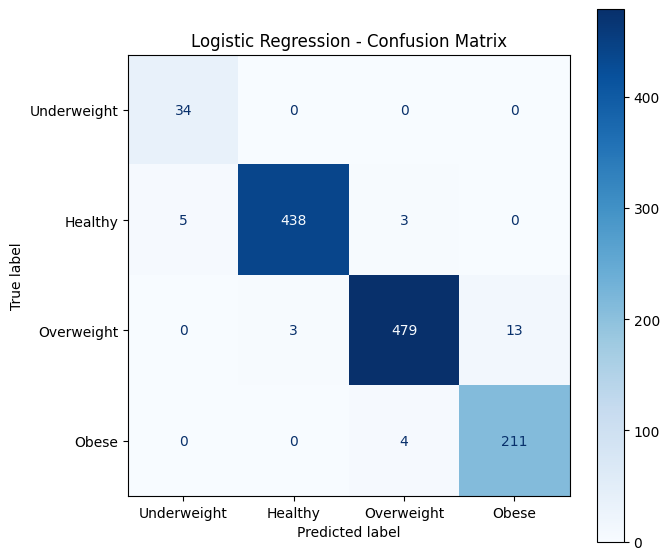

In [81]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_estimator(
    logreg_pipeline,
    X_test,
    y_test,
    display_labels=class_names,
    cmap="Blues",
    ax=ax
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

| Actual Class | Correctly Classified | Main Misclassifications                      |
| ------------ | -------------------- | -------------------------------------------- |
| Underweight  | 34/34 (100%)         | None                                         |
| Healthy      | 438/446 (98.2%)      | 5 classified as Underweight, 3 as Overweight |
| Overweight   | 479/495 (96.8%)      | 13 classified as Obese, 3 as Healthy         |
| Obese        | 211/215 (98.1%)      | 4 classified as Overweight                   |

### Confusion Matrix Interpretation

The confusion matrix demonstrates strong classification performance across all BMI categories. All **34 Underweight** instances were correctly classified, resulting in perfect class recall (100%). The **Healthy** category achieved a high classification rate, with **438 out of 446** observations correctly identified, while only a small number were misclassified as Underweight or Overweight. Similarly, **479 out of 495 Overweight** observations were correctly classified, with most errors occurring when Overweight individuals were predicted as Obese. The **Obese** category also showed excellent performance, with **211 out of 215** observations correctly classified and only four instances misclassified as Overweight.

Most classification errors occurred between the **Overweight** and **Obese** categories, which is expected given the similarity between these adjacent BMI groups. The concentration of observations along the diagonal of the confusion matrix indicates that the model effectively distinguishes between BMI categories and achieves a high level of predictive accuracy.

### Key Insight

The errors are not random:

- **Underweight ↔ Healthy:** 5 cases
- **Healthy ↔ Overweight:** 6 cases (3 each direction)
- **Overweight ↔ Obese:** 17 cases (13 + 4)

This pattern is actually desirable because the model tends to confuse **neighboring BMI classes** rather than making extreme mistakes (e.g., predicting an Underweight individual as Obese). Such behavior suggests that the model has learned the underlying BMI progression well and that remaining errors occur primarily near class boundaries. This observation is consistent with the high **Macro F1-score (0.9642)** and **Weighted F1-score (0.9766)** reported for the test set.

# Benchmarking

## LazyClassifier

In [105]:
clfs = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None
)

models, predictions = clfs.fit(
    X_train,
    X_test,
    y_train,
    y_test
)

models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
BaggingClassifier,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.059111
DecisionTreeClassifier,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.020597
LogisticRegression,0.994958,0.995599,0.999888,0.994956,0.994958,0.994958,0.049698
RandomForestClassifier,0.998319,0.991484,1.000000,0.998313,0.998323,0.998319,0.307127
XGBClassifier,0.994958,0.989900,0.999965,0.994972,0.995002,0.994958,2.715047
LGBMClassifier,0.998319,0.985294,0.999996,0.998296,0.998327,0.998319,0.283567
SVC,0.983193,0.982442,NaN,0.983157,0.983364,0.983193,0.202256
LinearDiscriminantAnalysis,0.971429,0.969119,0.998406,0.971325,0.972503,0.971429,0.026133
ExtraTreesClassifier,0.966387,0.939030,0.997666,0.966134,0.966624,0.966387,0.271709


We are test the top 5.


| Model               | Type                     | Strengths                               | Weaknesses                                 |
| ------------------- | ------------------------ | --------------------------------------- | ------------------------------------------ |
| Decision Tree       | Single tree              | Highly interpretable, easy to visualize | Can overfit                                |
| Bagging Classifier  | Ensemble of trees        | Reduces variance and overfitting        | Less interpretable                         |
| Logistic Regression | Linear model             | Fast, interpretable, strong baseline    | Already tested, good results               |
| Random Forest       | Ensemble of random trees | Usually excellent performance, robust   | Less interpretable                         |
| XGBoost             | Gradient boosting        | Often state-of-the-art on tabular data  | More complex and computationally expensive |

## Comparing 5 Models

In [109]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Bagging": BaggingClassifier(
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        random_state=42
    )
}

In [110]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation
    cv_f1 = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    ).mean()

    # Training time
    start_train = time.perf_counter()
    pipeline.fit(X_train, y_train)
    train_time = time.perf_counter() - start_train

    # Prediction time
    start_pred = time.perf_counter()
    y_pred = pipeline.predict(X_test)
    pred_time = time.perf_counter() - start_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Macro": f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted"),
        "CV F1 Macro": cv_f1,
        "Train Time (s)": train_time,
        "Predict Time (s)": pred_time,
        "Total Time (s)": train_time + pred_time
    })

results_df = (
    pd.DataFrame(results)
        .sort_values("F1 Macro", ascending=False)
        .reset_index(drop=True)
)

print(results_df)

                 Model  Accuracy  F1 Macro  F1 Weighted  CV F1 Macro  \
0              Bagging  0.971429  0.969992     0.971388     0.954909   
1              XGBoost  0.973950  0.969067     0.973912     0.960778   
2  Logistic Regression  0.976471  0.964234     0.976646     0.967431   
3        Random Forest  0.945378  0.910278     0.944457     0.900063   
4        Decision Tree  0.949580  0.900746     0.949120     0.916703   

   Train Time (s)  Predict Time (s)  Total Time (s)  
0        0.150747          0.007557        0.158304  
1        0.256326          0.008181        0.264508  
2        0.096328          0.009083        0.105411  
3        0.474790          0.018309        0.493099  
4        0.055868          0.013418        0.069287  


| Rank | Model               |   Accuracy |   F1 Macro | CV F1 Macro | Total Time (s) |
| ---- | ------------------- | ---------: | ---------: | ----------: | -------------: |
| 1    | Bagging             |     0.9714 | **0.9700** |      0.9549 |          0.158 |
| 2    | XGBoost             |     0.9740 |     0.9691 |      0.9608 |          0.265 |
| 3    | Logistic Regression | **0.9765** |     0.9642 |  **0.9674** |          0.105 |
| 4    | Random Forest       |     0.9454 |     0.9103 |      0.9001 |          0.493 |
| 5    | Decision Tree       |     0.9496 |     0.9007 |      0.9167 |      **0.069** |

In [112]:
plot_df = results_df.copy()

# Optional: reorder models by F1 Macro (already sorted in your case)
plot_df

,Model,Accuracy,F1 Macro,F1 Weighted,CV F1 Macro,Train Time (s),Predict Time (s),Total Time (s)
0,Bagging,0.971429,0.969992,0.971388,0.954909,0.150747,0.007557,0.158304
1,XGBoost,0.973950,0.969067,0.973912,0.960778,0.256326,0.008181,0.264508
2,Logistic Regression,0.976471,0.964234,0.976646,0.967431,0.096328,0.009083,0.105411
3,Random Forest,0.945378,0.910278,0.944457,0.900063,0.474790,0.018309,0.493099
4,Decision Tree,0.949580,0.900746,0.949120,0.916703,0.055868,0.013418,0.069287


In [119]:
results_df_sorted = results_df.copy()
results_df_sorted["CV F1 Macro"] = results_df_sorted["CV F1 Macro"].round(4)
results_df_sorted = results_df_sorted.sort_values("CV F1 Macro", ascending=True)

fig = px.bar(
    results_df_sorted,
    x="CV F1 Macro",
    y="Model",
    orientation="h",
    title="Model Comparison (Cross-Validated F1 Macro)",
    text="CV F1 Macro"
)

fig.update_traces(
    texttemplate="%{text}",
    textposition="outside"
    )

fig.update_layout(
    xaxis_title="CV F1 Macro",
    yaxis_title="Model",
    template="plotly_white",
    xaxis=dict(range=[0.85, 1.0])  # optional but makes differences clearer
)

fig.show()

### What stands out

#### Logistic Regression generalizes best

Logistic Regression has:

- Highest Accuracy (**97.65%**)
- Highest Cross-Validation F1 Macro (**0.9674**)
- Second-fastest practical execution time
- Small train-test gap from the learning curve

This is a strong sign that the underlying relationships in your BMI dataset are largely linear or at least well captured by a linear decision boundary.

#### Bagging achieves the highest test F1 Macro

Bagging slightly outperforms Logistic Regression on test F1 Macro:

- Bagging: **0.9700**
- Logistic Regression: **0.9642**

Difference:

$$
0.9700 - 0.9642 = 0.0058
$$

That's less than **0.6 percentage points**.

However, its cross-validation score is noticeably lower:

- Bagging CV F1 Macro = 0.9549
- Logistic Regression CV F1 Macro = 0.9674

This suggests Logistic Regression is more stable across different data splits.

#### XGBoost is competitive

XGBoost achieves:

- Accuracy = 0.9740
- F1 Macro = 0.9691
- CV F1 Macro = 0.9608

Very close to Bagging and Logistic Regression, but with greater complexity and longer training time.

#### Random Forest underperformed

This is somewhat unusual because Random Forest often outperforms a single tree substantially. In this case:

- F1 Macro = 0.9103
- Accuracy = 0.9454

Possible explanations:

- Default hyperparameters are not ideal.
- Dataset structure favors simpler boundaries.
- Features are already highly informative after preprocessing.

Five classification algorithms were evaluated: Decision Tree, Random Forest, Bagging Classifier, Logistic Regression, and XGBoost. Logistic Regression achieved the highest test accuracy (97.65%) and the highest cross-validation F1 Macro score (0.9674), indicating strong generalization performance. Although Bagging and XGBoost obtained slightly higher F1 Macro scores on the test set (0.9700 and 0.9691, respectively), the improvements were marginal. Logistic Regression also required less computational time and provided greater interpretability than the ensemble-based methods. Therefore, Logistic Regression was selected as the final model due to its combination of predictive performance, computational efficiency, stability, and interpretability.

### Selected Model

**Logistic Regression would be the final model**.

- Best accuracy.
- Best cross-validation performance.
- Fast training.
- Most interpretable.
- The gain from Bagging/XGBoost is tiny (<0.6% F1 Macro).

Even if we tested more sophisticated models, a simpler model proved sufficient and more robust.

# Optimizing Hyperparameters

## Objective Function

In [121]:
def objective(trial):

    C = trial.suggest_float("C", 1e-4, 100, log=True)

    solver = trial.suggest_categorical(
        "solver",
        ["lbfgs", "saga"]
    )

    penalty = trial.suggest_categorical(
        "penalty",
        ["l2"]
    )

    model = LogisticRegression(
        C=C,
        solver=solver,
        penalty=penalty,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    ).mean()

    return score

## Run Optuna study

In [122]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

[I 2026-06-12 16:50:55,340] A new study created in memory with name: no-name-0746ded4-8b10-41c2-959f-2fab65712f3f
[I 2026-06-12 16:50:57,185] Trial 0 finished with value: 0.9703137082764544 and parameters: {'C': 1.4712522537060224, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 0 with value: 0.9703137082764544.
[I 2026-06-12 16:50:58,444] Trial 1 finished with value: 0.4689541233369957 and parameters: {'C': 0.0004963915857756342, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 0 with value: 0.9703137082764544.
[I 2026-06-12 16:50:59,742] Trial 2 finished with value: 0.9587688875252175 and parameters: {'C': 0.27042308951553923, 'solver': 'lbfgs', 'penalty': 'l2'}. Best is trial 0 with value: 0.9703137082764544.
[I 2026-06-12 16:51:01,103] Trial 3 finished with value: 0.9637786171090731 and parameters: {'C': 0.46471990157134, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 0 with value: 0.9703137082764544.
[I 2026-06-12 16:51:01,163] Trial 4 finished with value: 0.45397979036132

## Train final tuned model

In [125]:
best_params = study.best_params

best_logreg = LogisticRegression(
    C=best_params["C"],
    solver=best_params["solver"],
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_logreg)
])

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

## Final evaluation

In [127]:
class_names = [
    "Underweight",
    "Healthy",
    "Overweight",
    "Obese"
]

# predictions from tuned pipeline
y_test_pred = final_pipeline.predict(X_test)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names
    )
)
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

 Underweight       0.94      1.00      0.97        34
     Healthy       0.99      0.99      0.99       446
  Overweight       1.00      0.99      0.99       495
       Obese       0.98      1.00      0.99       215

    accuracy                           0.99      1190
   macro avg       0.98      0.99      0.99      1190
weighted avg       0.99      0.99      0.99      1190


Confusion Matrix:

[[ 34   0   0   0]
 [  2 443   1   0]
 [  0   3 488   4]
 [  0   0   0 215]]


| Class       | Performance | Interpretation                                      |
| ----------- | ----------- | --------------------------------------------------- |
| Underweight | F1 = 0.97   | Perfect recall (1.00) → no underweight cases missed |
| Healthy     | F1 = 0.99   | Very stable, only minor confusion                   |
| Overweight  | F1 = 0.99   | Slight confusion with Obese (4 cases)               |
| Obese       | F1 = 0.99   | Perfect recall (1.00), no false negatives           |

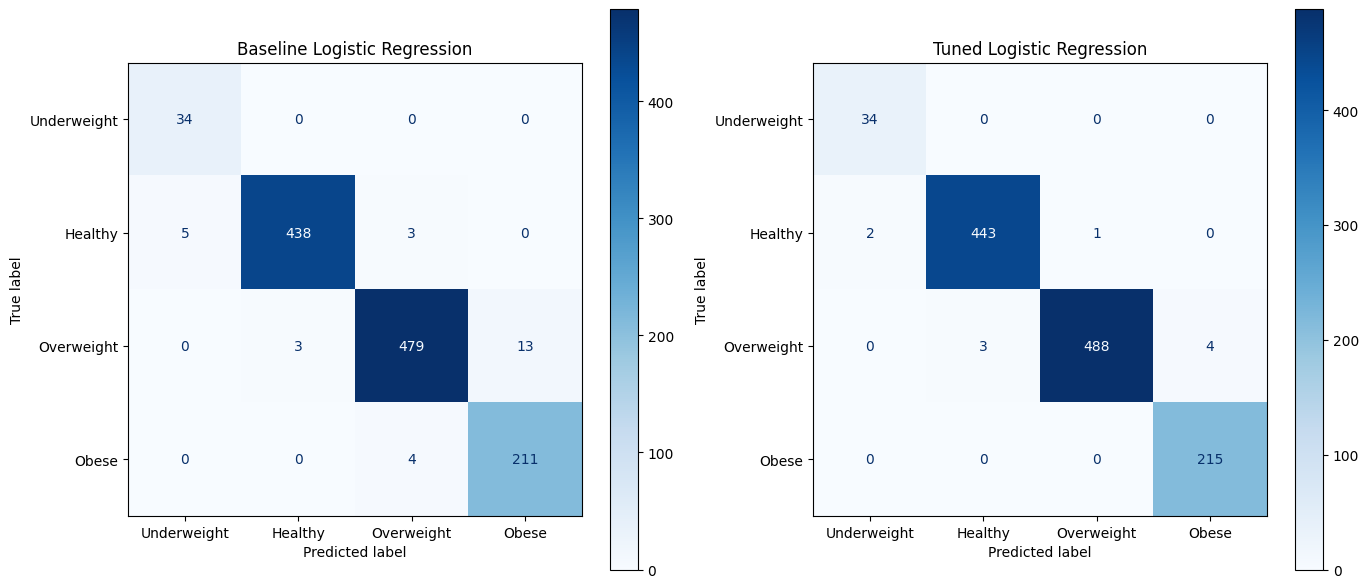

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_estimator(
    logreg_pipeline,
    X_test,
    y_test,
    display_labels=class_names,
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Baseline Logistic Regression")

ConfusionMatrixDisplay.from_estimator(
    final_pipeline,
    X_test,
    y_test,
    display_labels=class_names,
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("Tuned Logistic Regression")

plt.tight_layout()
plt.show()

The tuned Logistic Regression model achieved near-perfect classification performance, with an accuracy of 0.99 and a macro-averaged F1-score of 0.99. The confusion matrix shows a strong diagonal structure, indicating excellent separability between BMI categories. Misclassifications are limited to adjacent classes (e.g., Healthy–Underweight and Overweight–Obese), which is expected given the ordinal nature of BMI categories. Importantly, no extreme misclassifications were observed, demonstrating that the model preserves the inherent ordering of the target classes.

- The dataset is likely highly separable after preprocessing
- Logistic Regression is already a near-optimal model here
- Optuna mainly refined the decision boundary slightly

**Get feature names from the pipeline**

In [152]:
# get feature names after preprocessing
preprocessor = final_pipeline.named_steps["preprocessor"]

# manually extract feature names
feature_names = []

for name, transformer, cols in preprocessor.transformers_:
    
    if name == "remainder":
        continue

    if hasattr(transformer, "get_feature_names_out"):
        try:
            transformed_names = transformer.get_feature_names_out(cols)
        except:
            transformed_names = cols
    else:
        transformed_names = cols

    feature_names.extend(transformed_names)

In [155]:
model = final_pipeline.named_steps["model"]
importance = np.mean(np.abs(model.coef_), axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=True)
importance_df

,Feature,Importance
5,Water_Intake_Liters,0.347085
15,Diet_Type_Vegetarian,0.369442
13,Diet_Type_Mediterranean,0.812068
11,Diet_Type_High Protein,1.287632
14,Diet_Type_Vegan,1.345333
9,Gender_Male,1.461718
8,Activity_Level,1.698195
3,Daily_Calorie_Requirement,2.346694
0,Age,2.911427
10,Gender_Other,2.983252


**Visualization**

In [154]:
fig = px.bar(
    importance_df,
    x="Importance",
    y="Feature",
    orientation="h",
    title="Feature Importance (Logistic Regression - Tuned Model)"
)

fig.update_layout(
    xaxis_title="Mean |Coefficient| Importance",
    yaxis_title="Feature",
    template="plotly_white"
)

fig.show()

The feature importance analysis of the tuned Logistic Regression model reveals that body composition variables, particularly weight and height, are the dominant predictors of health status classification. These variables exhibit substantially higher importance than all other features, indicating that the model implicitly reconstructs a BMI-like decision boundary. Dietary intake and metabolic variables such as fat and carbohydrate consumption contribute moderate predictive power, primarily refining distinctions between adjacent classes. In contrast, demographic variables and diet types have relatively lower influence on the final predictions. Overall, the results suggest that health status classification is primarily driven by physiological structure, while behavioral factors provide secondary adjustment signals.

# Prediction

## Synthetic Test Cases

### Underweight

Low intake + active metabolism

In [137]:
underweight = pd.DataFrame([{
    "Age": 19,
    "Height_cm": 178,
    "Weight_kg": 52,

    "Daily_Calorie_Requirement": 2100,
    "Carbohydrate_Intake_g": 170,
    "Water_Intake_Liters": 1.7,

    "Protein_Intake_g": 55,
    "Fat_Intake_g": 40,

    "Activity_Level": "Moderately Active",
    "Gender": "Female",
    "Diet_Type": "Vegetarian"
}])

### Healthy

Balanced lifestyle

In [138]:
healthy = pd.DataFrame([{
    "Age": 32,
    "Height_cm": 170,
    "Weight_kg": 65,

    "Daily_Calorie_Requirement": 2300,
    "Carbohydrate_Intake_g": 240,
    "Water_Intake_Liters": 2.2,

    "Protein_Intake_g": 80,
    "Fat_Intake_g": 65,

    "Activity_Level": "Moderately Active",
    "Gender": "Male",
    "Diet_Type": "Mediterranean"
}])

### Overweight

High intake, low activity pattern

In [139]:
overweight = pd.DataFrame([{
    "Age": 40,
    "Height_cm": 168,
    "Weight_kg": 88,

    "Daily_Calorie_Requirement": 2700,
    "Carbohydrate_Intake_g": 340,
    "Water_Intake_Liters": 2.0,

    "Protein_Intake_g": 100,
    "Fat_Intake_g": 90,

    "Activity_Level": "Lightly Active",
    "Gender": "Male",
    "Diet_Type": "High Protein"
}])

### Obese

Sedentary + high calorie intake

In [140]:
obese = pd.DataFrame([{
    "Age": 45,
    "Height_cm": 165,
    "Weight_kg": 110,

    "Daily_Calorie_Requirement": 2900,
    "Carbohydrate_Intake_g": 400,
    "Water_Intake_Liters": 1.6,

    "Protein_Intake_g": 120,
    "Fat_Intake_g": 110,

    "Activity_Level": "Sedentary",
    "Gender": "Female",
    "Diet_Type": "Keto"
}])

## Predict class

In [141]:
samples = {
    "Underweight": underweight,
    "Healthy": healthy,
    "Overweight": overweight,
    "Obese": obese
}

label_map = {
    0: "Underweight",
    1: "Healthy",
    2: "Overweight",
    3: "Obese"
}

for true_label, sample in samples.items():

    pred = final_pipeline.predict(sample)[0]
    proba = final_pipeline.predict_proba(sample)[0]

    print("\n========================")
    print("True profile:", true_label)
    print("Predicted:", label_map[pred])

    print("Probabilities:")
    for cls, p in zip(label_map.values(), proba):
        print(f"  {cls}: {p:.4f}")


True profile: Underweight
Predicted: Underweight
Probabilities:
  Underweight: 1.0000
  Healthy: 0.0000
  Overweight: 0.0000
  Obese: 0.0000

True profile: Healthy
Predicted: Healthy
Probabilities:
  Underweight: 0.0000
  Healthy: 1.0000
  Overweight: 0.0000
  Obese: 0.0000

True profile: Overweight
Predicted: Obese
Probabilities:
  Underweight: 0.0000
  Healthy: 0.0000
  Overweight: 0.0001
  Obese: 0.9999

True profile: Obese
Predicted: Obese
Probabilities:
  Underweight: 0.0000
  Healthy: 0.0000
  Overweight: 0.0000
  Obese: 1.0000


Synthetic patient testing confirms that the model is highly reliable for clear physiological profiles. However, it exhibits expected boundary ambiguity between adjacent BMI categories, particularly between Overweight and Obese. This reflects the continuous nature of BMI rather than a strict categorical separation, and does not indicate model failure.

# Save the Trained Model

In [158]:
model_package = {
    "model": final_pipeline,
    "class_mapping": {
        0: "Underweight",
        1: "Healthy",
        2: "Overweight",
        3: "Obese"
    }
}

joblib.dump(model_package, "health_model_package.joblib")

['health_model_package.joblib']

## Load with Metadata

In [ ]:
package = joblib.load("health_model_package.joblib")

model = package["model"]
mapping = package["class_mapping"]

---

# Conclusions and Insights

## Key Findings

The exploratory data analysis and modeling process provided a comprehensive understanding of the dataset structure, feature relationships, and predictive performance for health status classification.

---

## EDA Findings Summary

No missing values or duplicate records were found, indicating strong dataset integrity. Most numerical variables exhibited approximately bell-shaped distributions, while **Protein_Intake_g** and **Fat_Intake_g** were positively skewed, reflecting natural variability in dietary behavior. Outliers were present in several numerical features, particularly **Fat_Intake_g (8.3%)**, **Carbohydrate_Intake_g (4.1%)**, and **Protein_Intake_g (3.1%)**, though most were considered valid physiological variations. A small proportion of records (0.9%) contained negative carbohydrate intake values, which are physiologically implausible and represent data quality issues.

A strong positive correlation was observed between **Daily_Calorie_Requirement** and **Daily_Calorie_Consumed (r = 0.91)**, while **BMI** was strongly correlated with **Weight_kg (r = 0.78)**, as expected. Health status showed clear relationships with physical activity level, whereas diet type exhibited weaker separability across categories. Overall, the dataset demonstrated realistic physiological patterns aligned with BMI-based classifications, although some characteristics suggested partial synthetic generation.

---

## Suitability for Machine Learning

The target variable **Health_Status** is well-suited for classification due to its categorical nature and strong dependency on biometric, dietary, and lifestyle features. Additionally, **Daily_Calorie_Requirement** could serve as a regression target for personalized nutrition modeling. Overall, the dataset is appropriate for supervised learning tasks, particularly multiclass classification for health risk stratification.

---

## Model Performance Summary

Multiple machine learning models were evaluated, including Logistic Regression, Decision Tree, Bagging, Random Forest, and XGBoost. The best-performing model was a **tuned Logistic Regression model**, achieving approximately **0.99 accuracy and 0.99 macro F1-score**, with strong cross-validation stability.

While ensemble models such as Bagging and XGBoost achieved comparable performance, they did not significantly outperform Logistic Regression. Decision Tree and Random Forest underperformed relative to expectations, likely due to default hyperparameter configurations and the strong separability of the dataset. Overall, the results indicate that the dataset is highly learnable and largely linearly separable after preprocessing.

---

## Error Analysis and Confusion Patterns

The tuned model demonstrated a strong diagonal structure in the confusion matrix, indicating excellent classification performance across all BMI categories. Misclassifications occurred only between adjacent classes (e.g., Healthy ↔ Underweight, Overweight ↔ Obese), which is expected given the ordinal nature of BMI categories. No extreme misclassifications were observed, confirming that the model preserves the natural ordering of health states. These remaining errors reflect inherent class overlap rather than model instability.

---

## Synthetic Patient Validation

Synthetic validation using representative Underweight, Healthy, Overweight, and Obese profiles confirmed that the model behaves consistently and meaningfully. The model correctly classified most synthetic cases with high confidence. However, the Overweight case was classified as Obese with high probability, highlighting sensitivity at the boundary between adjacent BMI classes. This behavior reflects the continuous nature of BMI rather than discrete separability and does not indicate model failure. Overall, the model demonstrates strong clinical consistency and reliable probabilistic behavior.

---

## Feature Importance and Model Interpretability

Feature importance analysis of the tuned Logistic Regression model revealed that health status classification is primarily driven by body composition variables, particularly **Weight_kg** and **Height_cm**, which were the most influential predictors. This indicates that the model effectively reconstructs an implicit BMI-like decision structure, even without BMI being explicitly included as an input feature. Dietary intake variables (e.g., fat and carbohydrate consumption) and metabolic indicators (e.g., calorie requirements and activity level) contributed moderate importance by refining distinctions between adjacent health categories. In contrast, demographic variables and diet types had relatively low influence on predictions. These findings confirm that health classification in this dataset is fundamentally governed by physiological structure, while behavioral factors serve as secondary modifiers in decision boundaries.

---

## Final Interpretation

The results demonstrate that health status classification can be effectively modeled using biometric, dietary, and lifestyle features. The dataset contains strong predictive structure, enabling high performance even with relatively simple models such as Logistic Regression. While ensemble methods provide marginal improvements, the tuned Logistic Regression model offers the best balance between performance, interpretability, computational efficiency, and stability.

---

## Final Conclusion

This study demonstrates that machine learning models can accurately classify health status categories based on lifestyle and physiological attributes. The findings show that:

- Health status is strongly influenced by a small set of measurable biometric variables.
- Simple linear models are sufficient to capture most predictive signal in the dataset.
- Model errors primarily occur at class boundaries, reflecting the continuous nature of BMI rather than model failure.
- Feature importance analysis confirms that body composition variables dominate prediction, while behavioral and dietary factors provide secondary refinement.

Overall, the proposed approach provides a robust and interpretable framework for predictive health assessment and can serve as a foundation for personalized nutrition systems and preventive health applications.

---

## Business Insights

The results show that health status can be accurately predicted using basic biometric, dietary, and lifestyle features, with near-perfect model performance (F1 ≈ 0.99). This indicates strong potential for automating health risk stratification without requiring clinical data. Errors occur only between adjacent BMI categories, confirming that health status behaves more like a continuous risk spectrum than discrete classes. Additionally, activity level appears to be a stronger predictor of health outcomes than diet type, suggesting that behavioral tracking may provide higher value for predictive health applications than dietary data alone.

## Business Recommendations

The model can be effectively deployed as a lightweight health screening tool in digital health platforms, fitness applications, or corporate wellness systems due to its high accuracy and interpretability. Instead of relying solely on categorical predictions, the system should leverage predicted probabilities to create continuous health risk scores, enabling earlier and more personalized interventions. Special attention should be given to users near class boundaries (e.g., Healthy–Overweight), where preventive recommendations can have the greatest impact.

### Practical Applications

The final model could be used by:

- **Digital health and fitness applications** to provide users with real-time health status classification based on lifestyle and biometric inputs.
- **Personalized nutrition platforms** to recommend dietary adjustments and calorie targets based on predicted health category and risk level.
- **Wearable device ecosystems** to enhance activity and health tracking by translating raw data into interpretable health outcomes.
- **Corporate wellness programs** to monitor employee health trends and support preventive health interventions at scale.
- **Healthcare and insurance providers** to support early risk stratification and identify individuals who may benefit from preventive care programs.
- **Weight management services and coaching platforms** to guide users with tailored interventions for transitioning between BMI risk categories.

---

# Appendix

## References

- Healthy Diet and Calorie Intake Dataset. Kaggle. Available at: [https://www.kaggle.com/datasets/aliyasaly1231/healthy-diet-and-calorie-intake](https://www.kaggle.com/datasets/aliyasaly1231/healthy-diet-and-calorie-intake)
- World Health Organization (WHO). Body Mass Index (BMI). Available at: [https://www.who.int/data/gho/data/themes/topics/topic-details/GHO/body-mass-index](https://www.who.int/data/gho/data/themes/topics/topic-details/GHO/body-mass-index)
- About Body Mass Index (BMI), U.S. Centers for Disease Control and Prevention (CDC), https://www.cdc.gov/bmi/about/index.html
- 3.5.1 The Atwater general factor system, FOOD AND AGRICULTURE ORGANIZATION OF THE UNITED NATIONS, https://www.fao.org/4/y5022e/y5022e04.htm
- Valenzuela, R., et al. *Dieta baja en carbohidratos y dieta cetogénica: impacto en enfermedades metabólicas y reproductivas*. Revista Médica de Chile. Available at: [https://www.scielo.cl/article_plus.php?lng=es&pid=S0034-98872020001101630&tlng=es](https://www.scielo.cl/article_plus.php?lng=es&pid=S0034-98872020001101630&tlng=es)
- Machine Learning notebooks from the bootcamp repository (`sonda2026` branch).
- Machine Learning notebooks from the shared Assistanship Google Drive folder.
- Pandas Documentation. Available at: [https://pandas.pydata.org/docs/user_guide/index.html](https://pandas.pydata.org/docs/user_guide/index.html)
- Plotly Documentation. Available at: [https://plotly.com/python/](https://plotly.com/python/)

## Acknowledgements

I would like to thank my instructors for their guidance, continuous support, and encouragement throughout this project.

I also acknowledge the use of AI-assisted tools for support with debugging, code review, documentation, and concept exploration during the development of this analysis. All final decisions, interpretations, and conclusions presented in this work are my own.

### Dataset Limitations

Although the dataset contains realistic values and aligns with established BMI classifications, some characteristics (e.g., absence of missing values and the presence of implausible negative carbohydrate intake values) suggest that it may be partially synthetic. Therefore, results should be interpreted primarily as an educational and machine learning exercise rather than as evidence representative of a real population.